# Task 2: Dự đoán LTV (Lifetime Value)

**Dataset:** `regression_data.csv`  
**Models:** OLS (statsmodels), LinearRegression đa biến (scikit-learn)

**Quy trình sau khi sửa theo feedback:**
```
Load data → Kiểm tra data → Split train/test
  → [Scale features (MinMaxScaler)]  ← STEP MỚI
  → [NẾU vẫn lệch → log1p features]
  → [log1p target (LTV)]
  → VIF check → OLS + LinearRegression → R², Adj R²
  → RMSE trên thang đo LTV gốc (£)   ← STEP MỚI
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

FEATURES = ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
TARGET   = 'LTV'
SKEW_THR = 1.0

## Bước 1 – Load & kiểm tra dữ liệu

In [2]:
df_raw = pd.read_csv('regression_data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (3601, 7)


,CustomerID,Total_Spend,Frequency,Total_Items,Unique_Products,Avg_Basket_Value,LTV
0,12346,77183.60,1,74215,1,77183.600,0.00
1,12347,2790.86,5,1590,82,558.172,1519.14
2,12348,1437.24,4,2332,21,359.310,0.00
3,12350,294.40,1,196,16,294.400,0.00
4,12352,1154.01,6,401,45,192.335,231.73


In [3]:
print('=== Kiểu dữ liệu ===')
print(df_raw.dtypes)
print('\n=== Missing values ===')
print(df_raw.isnull().sum())
print(f'  Tổng missing: {df_raw.isnull().sum().sum()}')
print('\n=== Duplicates ===')
print(f'  Duplicate rows      : {df_raw.duplicated().sum()}')
print(f'  Duplicate CustomerID: {df_raw["CustomerID"].duplicated().sum()}')
print('\n=== Describe (features + target) ===')
df_raw[FEATURES + [TARGET]].describe().T

=== Kiểu dữ liệu ===
CustomerID            int64
Total_Spend         float64
Frequency             int64
Total_Items           int64
Unique_Products       int64
Avg_Basket_Value    float64
LTV                 float64
dtype: object

=== Missing values ===
CustomerID          0
Total_Spend         0
Frequency           0
Total_Items         0
Unique_Products     0
Avg_Basket_Value    0
LTV                 0
dtype: int64
  Tổng missing: 0

=== Duplicates ===
  Duplicate rows      : 0
  Duplicate CustomerID: 0

=== Describe (features + target) ===


,count,mean,std,min,25%,50%,75%,max
Total_Spend,3601.0,1680.373941,6934.406737,2.9,280.55,590.00,1412.06,202443.64
Frequency,3601.0,3.614274,6.043114,1.0,1.00,2.00,4.00,136.00
Total_Items,3601.0,994.916968,4072.857697,1.0,139.00,331.00,820.00,143851.00
Unique_Products,3601.0,52.044710,71.867339,1.0,14.00,31.00,65.00,1462.00
Avg_Basket_Value,3601.0,405.530549,1387.520019,2.9,173.90,289.24,425.32,77183.60
LTV,3601.0,638.198853,3901.724587,0.0,0.00,80.46,524.90,168469.60


In [4]:
# Đánh giá chất lượng
issues = []
if df_raw.isnull().sum().sum() > 0:    issues.append('⚠ Có missing values')
if df_raw.duplicated().sum() > 0:      issues.append('⚠ Có duplicate rows')
for c in FEATURES + [TARGET]:
    if (df_raw[c] < 0).sum() > 0:     issues.append(f'⚠ {c} có giá trị âm')

if not issues:
    print('✓ Dữ liệu ĐÃ SẠCH – không missing, không duplicate, không âm')
    print('  → Không cần làm sạch, tiến hành preprocessing')
else:
    for i in issues: print(i)

# Loại CustomerID (định danh, không dùng để dự đoán)
df = df_raw[FEATURES + [TARGET]].copy()
print(f'\nFeatures: {FEATURES}')
print(f'Target  : {TARGET}')
print(f'\nLưu ý: LTV có {(df[TARGET]==0).sum()} giá trị = 0 ({(df[TARGET]==0).mean()*100:.1f}% - KH chỉ mua 1 lần)')

✓ Dữ liệu ĐÃ SẠCH – không missing, không duplicate, không âm
  → Không cần làm sạch, tiến hành preprocessing

Features: ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
Target  : LTV

Lưu ý: LTV có 1755 giá trị = 0 (48.7% - KH chỉ mua 1 lần)


## Bước 2 – Chia Train / Test (TRƯỚC khi preprocessing)

> **Quan trọng:** Phải split trước, sau đó fit scaler/transform **chỉ trên train**  
> để tránh *data leakage* (thông tin từ test ảnh hưởng vào quá trình huấn luyện).

In [5]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')

Train: 2880 (80%)
Test : 721 (20%)


## Bước 3 – Preprocessing: SCALE trước → kiểm tra skewness → LOG nếu lệch

**Lý do scale trước:**  
Các features có scale rất khác nhau (ví dụ `Frequency` ~140, `Total_Spend` ~200,000).  
Nếu đưa thẳng vào mô hình, đặc trưng có giá trị lớn sẽ "lấn át" đặc trưng nhỏ.

**Quy trình:**
1. `MinMaxScaler` → đưa tất cả features về [0, 1]
2. Kiểm tra skewness sau khi scale
3. **NẾU** `|skewness| > 1.0` → áp dụng `log1p`

In [6]:
# ─── Step 1: MinMaxScaler cho features ───────────────────────────────
scaler_X = MinMaxScaler()
Xtr_sc = pd.DataFrame(scaler_X.fit_transform(X_train), columns=FEATURES, index=X_train.index)
Xte_sc = pd.DataFrame(scaler_X.transform(X_test),      columns=FEATURES, index=X_test.index)

print('=== Skewness TRƯỚC và SAU MinMaxScaler (features) ===')
skew_raw  = X_train.skew()
skew_scal = Xtr_sc.skew()
skew_cmp = pd.DataFrame({
    'Skew (gốc)' : skew_raw.round(2),
    'Skew (scaled)': skew_scal.round(2),
    'Cần log1p?': ['Có ✓' if abs(v)>SKEW_THR else 'Không ✗' for v in skew_scal]
})
print(skew_cmp.to_string())

# ─── Step 2: log1p nếu |skew| > threshold ───────────────────────────
Xtr = Xtr_sc.copy(); Xte = Xte_sc.copy()
feats_log = []
for col in FEATURES:
    if abs(Xtr_sc[col].skew()) > SKEW_THR:
        Xtr[col] = np.log1p(Xtr_sc[col])
        Xte[col] = np.log1p(Xte_sc[col])
        feats_log.append(col)

print(f'\nSau log1p – skewness features:')
print(Xtr.skew().round(3).to_string())
print(f'\nCột áp dụng log1p: {feats_log}')

=== Skewness TRƯỚC và SAU MinMaxScaler (features) ===
                  Skew (gốc)  Skew (scaled) Cần log1p?
Total_Spend            19.15          19.15       Có ✓
Frequency               9.91           9.91       Có ✓
Total_Items            20.26          20.26       Có ✓
Unique_Products         7.23           7.23       Có ✓
Avg_Basket_Value       13.66          13.66       Có ✓

Sau log1p – skewness features:
Total_Spend         15.636
Frequency            7.351
Total_Items         15.813
Unique_Products      5.095
Avg_Basket_Value     9.896

Cột áp dụng log1p: ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']


In [7]:
# ─── Target (LTV): log1p trực tiếp ─────────────────────────────────
# Không dùng MinMaxScaler cho target vì LTV có extreme outlier
# (y_test max = 168,469 >> y_train max = 79,498 → MinMaxScaler ngoại suy)
# log1p đủ để xử lý skewness và robust với outlier

skew_ltv_raw = float(pd.Series(y_train.values).skew())
print(f'LTV Skew (gốc): {skew_ltv_raw:.2f}')

y_log_applied = abs(skew_ltv_raw) > SKEW_THR
if y_log_applied:
    ytr = np.log1p(y_train.values)
    yte = np.log1p(y_test.values)
    print(f'→ Áp dụng log1p cho LTV: skew sau = {pd.Series(ytr).skew():.3f}')
else:
    ytr = y_train.values; yte = y_test.values
    print('→ LTV không lệch, giữ nguyên')

print(f'\nPipeline target: LTV → log1p → X')
print('Inverse:         X → expm1 → LTV (£)  [dùng để tính RMSE gốc]')

LTV Skew (gốc): 18.20
→ Áp dụng log1p cho LTV: skew sau = 0.124

Pipeline target: LTV → log1p → X
Inverse:         X → expm1 → LTV (£)  [dùng để tính RMSE gốc]


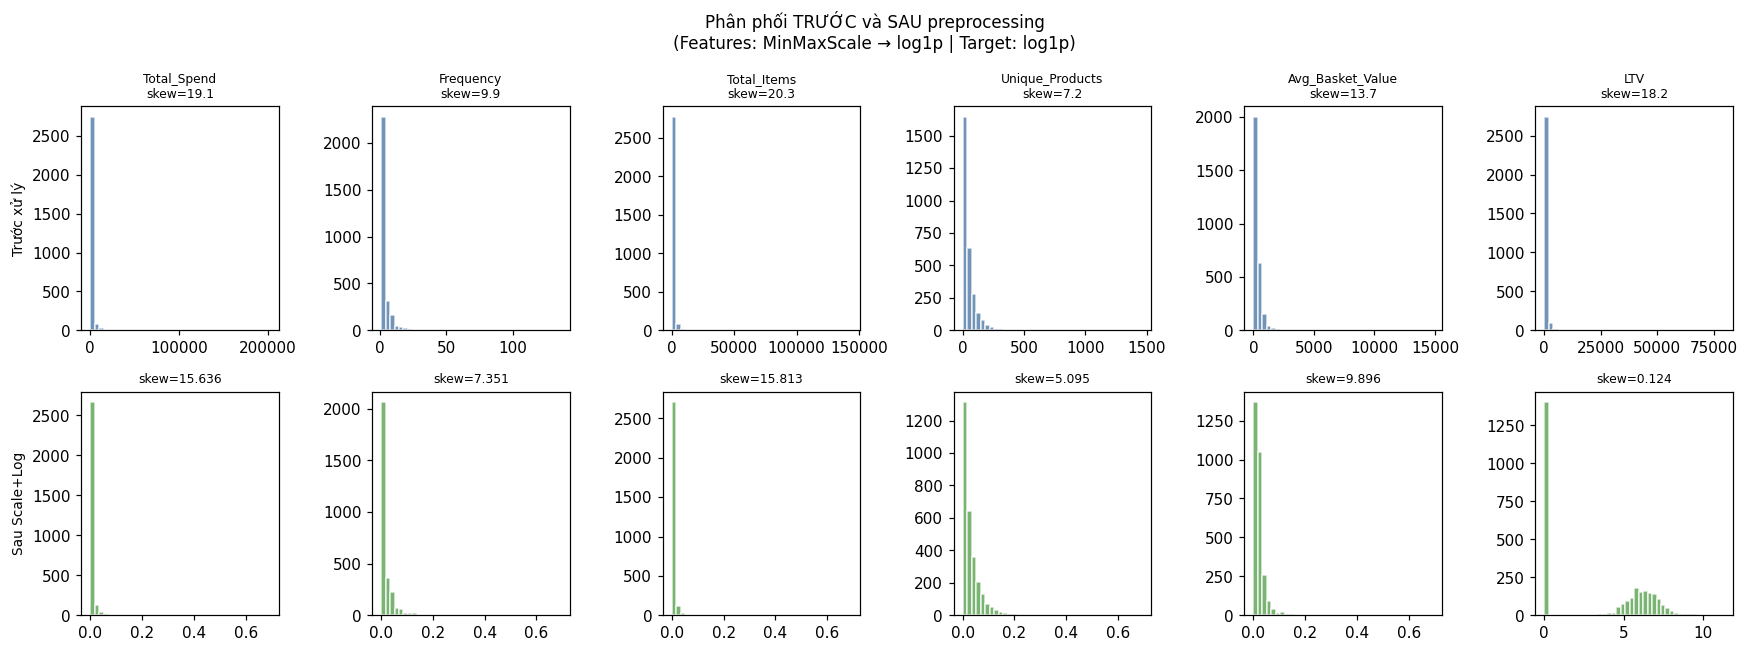

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

cols_plot = FEATURES + [TARGET]
raw_data  = [X_train[c] for c in FEATURES] + [y_train]
proc_data = [Xtr[c] for c in FEATURES]    + [pd.Series(ytr)]

for i, (col, raw, proc) in enumerate(zip(cols_plot, raw_data, proc_data)):
    axes[0, i].hist(raw,  bins=40, color='#4e79a7', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col}\nskew={pd.Series(raw.values).skew():.1f}', fontsize=8)
    axes[1, i].hist(proc, bins=40, color='#59a14f', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'skew={pd.Series(proc.values).skew():.3f}', fontsize=8)

axes[0, 0].set_ylabel('Trước xử lý', fontsize=9)
axes[1, 0].set_ylabel('Sau Scale+Log', fontsize=9)
plt.suptitle('Phân phối TRƯỚC và SAU preprocessing\n(Features: MinMaxScale → log1p | Target: log1p)', fontsize=11)
plt.tight_layout(); plt.show()

## Bước 4 – Kiểm tra Đa cộng tuyến (VIF)

| VIF | Mức độ |
|---|---|
| < 5 | Bình thường |
| 5 – 10 | Cảnh báo |
| ≥ 10 | Nghiêm trọng → cần xử lý |

=== VIF ban đầu ===
         Feature  VIF      Đánh giá
     Total_Spend 8.95    ⚠ Cảnh báo
     Total_Items 7.50    ⚠ Cảnh báo
       Frequency 2.78 ✓ Bình thường
 Unique_Products 2.04 ✓ Bình thường
Avg_Basket_Value 1.56 ✓ Bình thường


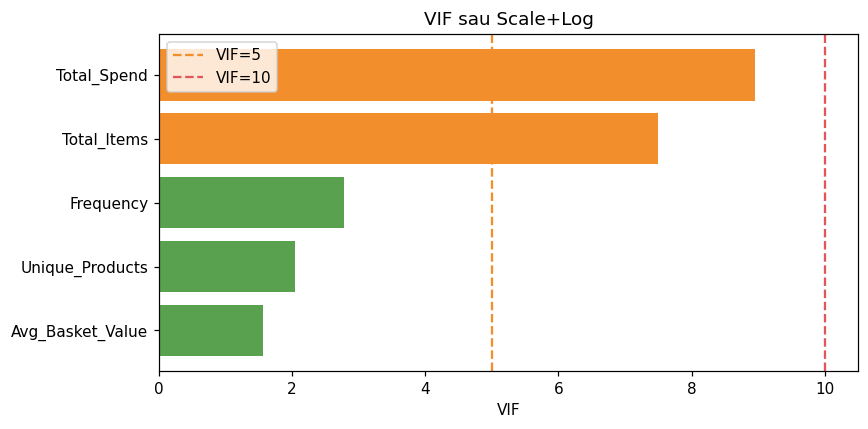

In [9]:
# VIF trên tập train đã xử lý
X_c0 = sm.add_constant(Xtr)
vif_init = pd.DataFrame({
    'Feature': X_c0.columns,
    'VIF': [variance_inflation_factor(X_c0.values, i) for i in range(X_c0.shape[1])]
})
vif_init = vif_init[vif_init['Feature']!='const'].copy()
vif_init['VIF'] = vif_init['VIF'].round(2)
vif_init['Đánh giá'] = vif_init['VIF'].apply(
    lambda v: '✓ Bình thường' if v<5 else ('⚠ Cảnh báo' if v<10 else '✗ Nghiêm trọng'))
print('=== VIF ban đầu ===')
print(vif_init.sort_values('VIF', ascending=False).to_string(index=False))

# Biểu đồ
fig, ax = plt.subplots(figsize=(8, 4))
vif_s = vif_init.sort_values('VIF')
colors = ['#e15759' if v>=10 else '#f28e2b' if v>=5 else '#59a14f' for v in vif_s['VIF']]
ax.barh(vif_s['Feature'], vif_s['VIF'], color=colors)
ax.axvline(5,  ls='--', color='#f28e2b', lw=1.5, label='VIF=5')
ax.axvline(10, ls='--', color='#e15759', lw=1.5, label='VIF=10')
ax.set_xlabel('VIF'); ax.set_title('VIF sau Scale+Log')
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# Iterative VIF Elimination
VIF_THRESH = 10.0
selected = FEATURES.copy(); dropped = []

for iteration in range(len(FEATURES)):
    Xc = sm.add_constant(Xtr[selected])
    vif_it = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
        index=Xc.columns).drop('const')
    if vif_it.max() <= VIF_THRESH:
        print(f'Vòng {iteration}: Tất cả VIF ≤ {VIF_THRESH} → DỪNG'); break
    worst = vif_it.idxmax()
    print(f'Vòng {iteration}: Loại "{worst}" (VIF={vif_it.max():.1f})')
    dropped.append(worst); selected.remove(worst)

print(f'\nBiến bị loại : {dropped if dropped else "Không có"}')
print(f'Biến còn lại : {selected}')

# VIF final
Xc_f = sm.add_constant(Xtr[selected])
vif_f = pd.DataFrame({
    'Feature': Xc_f.columns,
    'VIF': [variance_inflation_factor(Xc_f.values, i) for i in range(Xc_f.shape[1])]
})
vif_f = vif_f[vif_f['Feature']!='const'].copy()
print('\nVIF sau xử lý:')
print(vif_f.round(2).to_string(index=False))

Vòng 0: Tất cả VIF ≤ 10.0 → DỪNG

Biến bị loại : Không có
Biến còn lại : ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']

VIF sau xử lý:
         Feature  VIF
     Total_Spend 8.95
       Frequency 2.78
     Total_Items 7.50
 Unique_Products 2.04
Avg_Basket_Value 1.56


## Bước 5 – Mô hình hồi quy
### 5.1 OLS (statsmodels)

In [11]:
n_tr = len(Xtr); k = len(selected)
Xtr_c = sm.add_constant(Xtr[selected])
Xte_c = sm.add_constant(Xte[selected])

ols = sm.OLS(ytr, Xtr_c).fit()
print(ols.summary())

yp_ols_tr = np.array(ols.predict(Xtr_c))
yp_ols_te = np.array(ols.predict(Xte_c))

r2_ols_tr  = r2_score(ytr, yp_ols_tr)
r2_ols_te  = r2_score(yte, yp_ols_te)
adj_r2_ols = 1 - (1 - r2_ols_tr) * (n_tr - 1) / (n_tr - k - 1)

print(f'\n=== OLS – Đánh giá ===')
print(f'  R² Train    : {r2_ols_tr:.4f}')
print(f'  Adj R²      : {adj_r2_ols:.4f}')
print(f'  R² Test     : {r2_ols_te:.4f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     124.4
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.71e-119
Time:                        17:13:24   Log-Likelihood:                -7181.5
No. Observations:                2880   AIC:                         1.438e+04
Df Residuals:                    2874   BIC:                         1.441e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.2281      0.082  

### 5.2 LinearRegression đa biến (scikit-learn)

In [12]:
lr = LinearRegression()
lr.fit(Xtr[selected], ytr)

yp_lr_tr = lr.predict(Xtr[selected])
yp_lr_te = lr.predict(Xte[selected])

r2_lr_tr  = r2_score(ytr, yp_lr_tr)
r2_lr_te  = r2_score(yte, yp_lr_te)
adj_r2_lr = 1 - (1 - r2_lr_tr) * (n_tr - 1) / (n_tr - k - 1)

print('=== LinearRegression sklearn – R² và Adjusted R² ===')
print(f'  R² Train  : {r2_lr_tr:.4f}')
print(f'  Adj R²    : {adj_r2_lr:.4f}')
print(f'  R² Test   : {r2_lr_te:.4f}')

print('\n=== Hệ số hồi quy ===')
coef_df = pd.DataFrame({'Feature': selected, 'Coefficient': lr.coef_})
print(f'Intercept: {lr.intercept_:.4f}')
print(coef_df.to_string(index=False))

=== LinearRegression sklearn – R² và Adjusted R² ===
  R² Train  : 0.1779
  Adj R²    : 0.1765
  R² Test   : 0.1918

=== Hệ số hồi quy ===
Intercept: 2.2281
         Feature  Coefficient
     Total_Spend     2.130735
       Frequency    20.707556
     Total_Items    -4.297309
 Unique_Products    15.448721
Avg_Basket_Value     4.219430


## Bước 6 – RMSE trên thang đo LTV gốc (£)

**Tại sao cần tính RMSE gốc?**  
Mô hình dự đoán trên thang `log1p(LTV)` – RMSE trên thang này **không có ý nghĩa thực tế**.  
Cần đảo ngược biến đổi để biết sai số thực sự (đơn vị £):

```
ŷ_log  →  expm1(ŷ_log)  →  ŷ_LTV (£)
```

In [13]:
# Reverse pipeline: prediction (log scale) → expm1 → LTV (£)
def to_orig_ltv(y_pred_log):
    return np.expm1(np.array(y_pred_log))

yp_ols_orig = to_orig_ltv(yp_ols_te)
yp_lr_orig  = to_orig_ltv(yp_lr_te)
y_test_arr  = y_test.values

def eval_orig(name, y_pred_orig):
    rmse = np.sqrt(mean_squared_error(y_test_arr, y_pred_orig))
    mae  = np.mean(np.abs(y_test_arr - y_pred_orig))
    print(f'{name}:')
    print(f'  RMSE (£) = {rmse:>10,.0f}')
    print(f'  MAE  (£) = {mae:>10,.0f}')
    return rmse, mae

print(f'Mean LTV test : {y_test_arr.mean():>10,.0f} £')
print(f'Std  LTV test : {y_test_arr.std():>10,.0f} £')
print()
rmse_ols, mae_ols = eval_orig('OLS',              yp_ols_orig)
print()
rmse_lr,  mae_lr  = eval_orig('LinearRegression', yp_lr_orig)

Mean LTV test :        764 £
Std  LTV test :      6,543 £

OLS:
  RMSE (£) =      7,026
  MAE  (£) =        859

LinearRegression:
  RMSE (£) =      7,026
  MAE  (£) =        859


## Bước 7 – Tổng kết

=== BẢNG KẾT QUẢ ===
                 Mô hình  R² Train  Adj R²  R² Test  RMSE (£)  MAE  (£)
                     OLS    0.1779  0.1765   0.1918    7026.0     859.0
LinearRegression sklearn    0.1779  0.1765   0.1918    7026.0     859.0

=== QUY TRÌNH ĐÃ THỰC HIỆN ===
  1. Kiểm tra data          : SẠCH (0 missing, 0 duplicate)
  2. Scale features         : MinMaxScaler [0,1] (đưa về cùng thang đo)
  3. Log transform features : 5/5 cột lệch → log1p
  4. Log transform target   : log1p(LTV) (skew=18.2)
  5. VIF elimination        : Loại không có biến nào
  6. Features sử dụng       : ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
  7. RMSE gốc OLS           : £7,026 (dự đoán lệch ~919% so với mean LTV)


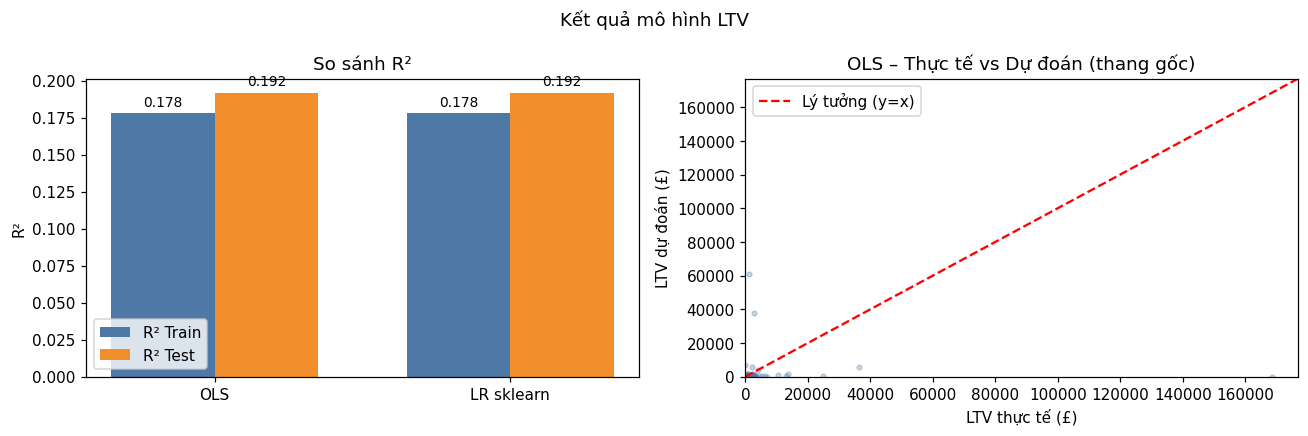

In [14]:
summary = pd.DataFrame({
    'Mô hình'   : ['OLS', 'LinearRegression sklearn'],
    'R² Train'  : [round(r2_ols_tr,  4), round(r2_lr_tr,  4)],
    'Adj R²'    : [round(adj_r2_ols, 4), round(adj_r2_lr, 4)],
    'R² Test'   : [round(r2_ols_te,  4), round(r2_lr_te,  4)],
    'RMSE (£)'  : [round(rmse_ols, 0),   round(rmse_lr, 0)],
    'MAE  (£)'  : [round(mae_ols, 0),    round(mae_lr, 0)],
})
print('=== BẢNG KẾT QUẢ ===')
print(summary.to_string(index=False))

print(f'\n=== QUY TRÌNH ĐÃ THỰC HIỆN ===')
print(f'  1. Kiểm tra data          : SẠCH (0 missing, 0 duplicate)')
print(f'  2. Scale features         : MinMaxScaler [0,1] (đưa về cùng thang đo)')
print(f'  3. Log transform features : {len(feats_log)}/{len(FEATURES)} cột lệch → log1p')
print(f'  4. Log transform target   : log1p(LTV) (skew={skew_ltv_raw:.1f})')
print(f'  5. VIF elimination        : Loại {dropped if dropped else "không có biến nào"}')
print(f'  6. Features sử dụng       : {selected}')
print(f'  7. RMSE gốc OLS           : £{rmse_ols:,.0f} (dự đoán lệch ~{rmse_ols/y_test_arr.mean()*100:.0f}% so với mean LTV)')

# Biểu đồ so sánh R²
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(2); w = 0.35
axes[0].bar(x-w/2, [r2_ols_tr, r2_lr_tr], w, label='R² Train', color='#4e79a7')
axes[0].bar(x+w/2, [r2_ols_te, r2_lr_te], w, label='R² Test',  color='#f28e2b')
axes[0].set_xticks(x); axes[0].set_xticklabels(['OLS', 'LR sklearn'])
axes[0].set_ylabel('R²'); axes[0].set_title('So sánh R²'); axes[0].legend()
for i, (tr, te) in enumerate([(r2_ols_tr,r2_ols_te),(r2_lr_tr,r2_lr_te)]):
    axes[0].text(i-w/2, tr+0.005, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, te+0.005, f'{te:.3f}', ha='center', fontsize=9)

# Scatter predicted vs actual (OLS)
axes[1].scatter(y_test_arr, yp_ols_orig, alpha=0.3, s=10, color='#4e79a7')
lim = max(y_test_arr.max(), yp_ols_orig.max())*1.05
axes[1].plot([0, lim],[0, lim], 'r--', lw=1.5, label='Lý tưởng (y=x)')
axes[1].set_xlabel('LTV thực tế (£)'); axes[1].set_ylabel('LTV dự đoán (£)')
axes[1].set_title('OLS – Thực tế vs Dự đoán (thang gốc)')
axes[1].legend(); axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)

plt.suptitle('Kết quả mô hình LTV', fontsize=12)
plt.tight_layout(); plt.show()